# 경로손실 등고선 곡면으로 기지국 커버리지 지도화하기


## 핵심 요약

통신사 RF 계획팀이 단일 매크로셀 주변의 하향링크 **경로손실 곡면**을 2차원 커버리지 지도로 렌더링합니다. 로그-거리 전파 모델과 로그정규 섀도우 페이딩을 사용해, 이 노트북은 100포인트 측정 격자(10km x 10km 서비스 영역에 걸친 10 x 10 셀, 기지국은 중앙에 위치)를 구성하고, **PROC SGPLOT의 HEATMAPPARM**과 그라디언트 색상 스케일, 기지국 기준선을 이용해 채워진 등고선 곡면을 그립니다.

실행된 격자에서 경로손실은 기지국 부근의 밝은 저점인 **50.4 dB**에서 가장 먼 모서리의 **90.0 dB**까지 분포하며, 평균 **75.6 dB**입니다. 각 셀을 손실 기준으로 분류하면 **강함 38개, 양호 61개, 약함 1개** 셀이 나옵니다. 유일한 약함 셀은 **(9.5, 9.5) km — 기지국의 대각선 반대편 모서리 — 에서 89.97 dB**를 기록하는데, 이는 소형셀 보강 결정을 내리기 전에 계획자가 표시할 단 하나의 커버리지 홀입니다.

> **프로시저에 대한 참고사항.** SAS에서 등고선 지도를 그리는 전통적인 도구는 `PROC GCONTOUR`입니다. Jenner는 GCONTOUR를 파싱하고 올바른 플롯 스펙을 생성하지만, 래스터 렌더러가 아직 등고선 기하를 그리지 못합니다(이미지가 비어서 반환됩니다). 이 결함은 회귀 테스트 `tests/400922_nb_gcontour_empty_render`로 등록되어 있습니다. 이 예제를 실제로 렌더링된 그림에 온전히 기반하도록 하기 위해, 우리는 SAS 호환 대안인 `PROC SGPLOT`의 `HEATMAPPARM` 문을 사용합니다 — 이는 동일한 격자형 (x, y, z) 곡면을 그라디언트 범례가 있는 채워진 등고선 셀로 렌더링합니다.

## 데이터 소스

**합성 데이터셋: `pathloss_grid`** (100행 — 10 x 10 격자)

| 변수 | 유형 | 단위 | 설명 |
|----------|------|-------|-------------|
| `east_km` | 수치형 | km | 격자 셀 중심의 동쪽 좌표(0.5 ~ 9.5); x축 |
| `north_km` | 수치형 | km | 격자 셀 중심의 북쪽 좌표(0.5 ~ 9.5); y축 |
| `path_loss` | 수치형 | dB | 하향링크 경로손실 = 58 + 30 log10(거리) + 섀도우; 응답값(z) |
| `zone` | 문자(10) | — | 커버리지 등급: 강함(<=75), 양호(<=88), 약함(>88) |

기지국은 격자 중앙 **(5, 5) km**에 위치합니다. 경로손실은 기지국으로부터의 거리의 상용로그에 비례해 증가합니다. `3*rand("normal")` 섀도우 항(시드 80211)이 로그정규 페이딩을 주입해 등고선이 완벽한 원형이 되지 않도록 합니다. 10 x 10 격자는 전체 곡면이 100개 관측값에 들어맞도록 크기가 정해졌습니다.

## 1단계 — 측정 격자 생성

셀 중심의 1km 격자를 배치하고, **로그-거리 모델** `PL = 58 + 30 log10(d)`로 경로손실을 계산합니다. 여기서 `d`는 (5, 5) km에 위치한 기지국으로부터의 거리입니다. `rand("normal")` 섀도우 페이딩 항이 실제 드라이브 테스트에서 관찰되는 변동성을 재현합니다. 각 셀은 커버리지 `zone`으로 분류됩니다. `call streaminit`이 재현성을 위해 시드를 고정합니다.

In [1]:
데이터 pathloss_grid;
   호출 streaminit(80211);
   길이 zone $10;
   tower_x = 5.0;  tower_y = 5.0;
   반복 ix = 1 까지 10;
      반복 iy = 1 까지 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         만약      path_loss <= 75 이면 zone = "강함";
         아니면 만약 path_loss <= 88 이면 zone = "양호";
         아니면                         zone = "약함";
         출력;
      종료;
   종료;
   제거 ix iy tower_x tower_y DIST shadow;
   라벨 east_km   = "동쪽 거리(km)"
         north_km  = "북쪽 거리(km)"
         path_loss = "경로손실(dB)"
         zone      = "커버리지 등급";
실행;



NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 2단계 — 곡면 요약

플롯을 그리기 전에 곡면을 수치화합니다. `PROC MEANS`는 경로손실의 동적 범위를 보고하고, `PROC FREQ`는 100개 셀이 세 커버리지 등급에 어떻게 분포하는지 집계합니다 — 핵심 요약에서 인용한 수치들입니다.

In [2]:
ODS GRAPHICS OFF;

처리 평균 데이터=pathloss_grid MIN MAX mean maxdec=1;
   변수 path_loss;
   라벨 path_loss = "경로손실(dB)";
실행;

처리 빈도 데이터=pathloss_grid ORDER=빈도;
   TABLES zone / nocum;
   라벨 zone = "커버리지 등급";
실행;


                                                  The MEANS Procedure

 Variable   Label                Minimum     Maximum        Mean
 ---------------------------------------------------------------
 path_loss  경로손실(dB)                50.4        90.0        75.6
 ---------------------------------------------------------------

                                                   The FREQ Procedure

커버리지 등급                Frequency    Percent
--------------------------------------------
양호                            61     61.00
강함                            38     38.00
약함                             1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## 3단계 — 커버리지 홀 찾기

경로손실 내림차순으로 정렬하면 가장 약한 셀이 맨 위로 옵니다. 이들은 계획자가 점검하는 후보 **불통 구역**입니다: 수신 신호가 가장 낮아 세션 끊김이나 낮은 처리량의 위험이 가장 큰 셀들입니다.

In [3]:
처리 정렬 데이터=pathloss_grid out=weakest;
   기준 DESCENDING path_loss;
실행;

처리 인쇄 데이터=weakest(obs=6) noobs 라벨;
   변수 east_km north_km path_loss zone;
   라벨 east_km   = "동쪽 거리(km)"
         north_km  = "북쪽 거리(km)"
         path_loss = "경로손실(dB)"
         zone      = "커버리지 등급";
실행;



        동쪽 거리(km)          북쪽 거리(km)          경로손실(dB)              커버리지 등급
-----------------  -----------------  ----------------  -------------------
              9.5                9.5     89.9728891641  약함
              9.5                0.5     85.9296978639  양호
              6.5                0.5     84.5845683025  양호
              0.5                0.5     84.5118930355  양호
              8.5                0.5     84.1534148341  양호
              9.5                8.5     83.7015943773  양호

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## 4단계 — 경로손실 등고선 곡면 그리기

`HEATMAPPARM x=east_km y=north_km colorresponse=path_loss`는 격자점마다 채워진 셀 하나를 그 경로손실 값으로 색칠해 렌더링합니다 — 커버리지 영역의 채워진 등고선 지도입니다. `COLORMODEL=` 목록은 파랑-빨강 발산 그라디언트를 정의하며(파랑 = 낮은 손실 = 강한 신호, 빨강 = 높은 손실 = 약한 신호), `GRADLEGEND`가 dB 색상 스케일을 붙입니다. 점선 `REFLINE`은 동쪽 좌표 5와 북쪽 좌표 5에 위치한 기지국을 표시합니다.

                                                    하향링크 경로손실 곡면(dB)                                                    
                                         10 x 10 km 격자 위 (5, 5) km 지점의 단일 매크로셀                                          




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to 하향링크 경로손실 곡면(dB).
NOTE: Option TITLE2 changed to 10 x 10 km 격자 위 (5, 5) km 지점의 단일 매크로셀.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


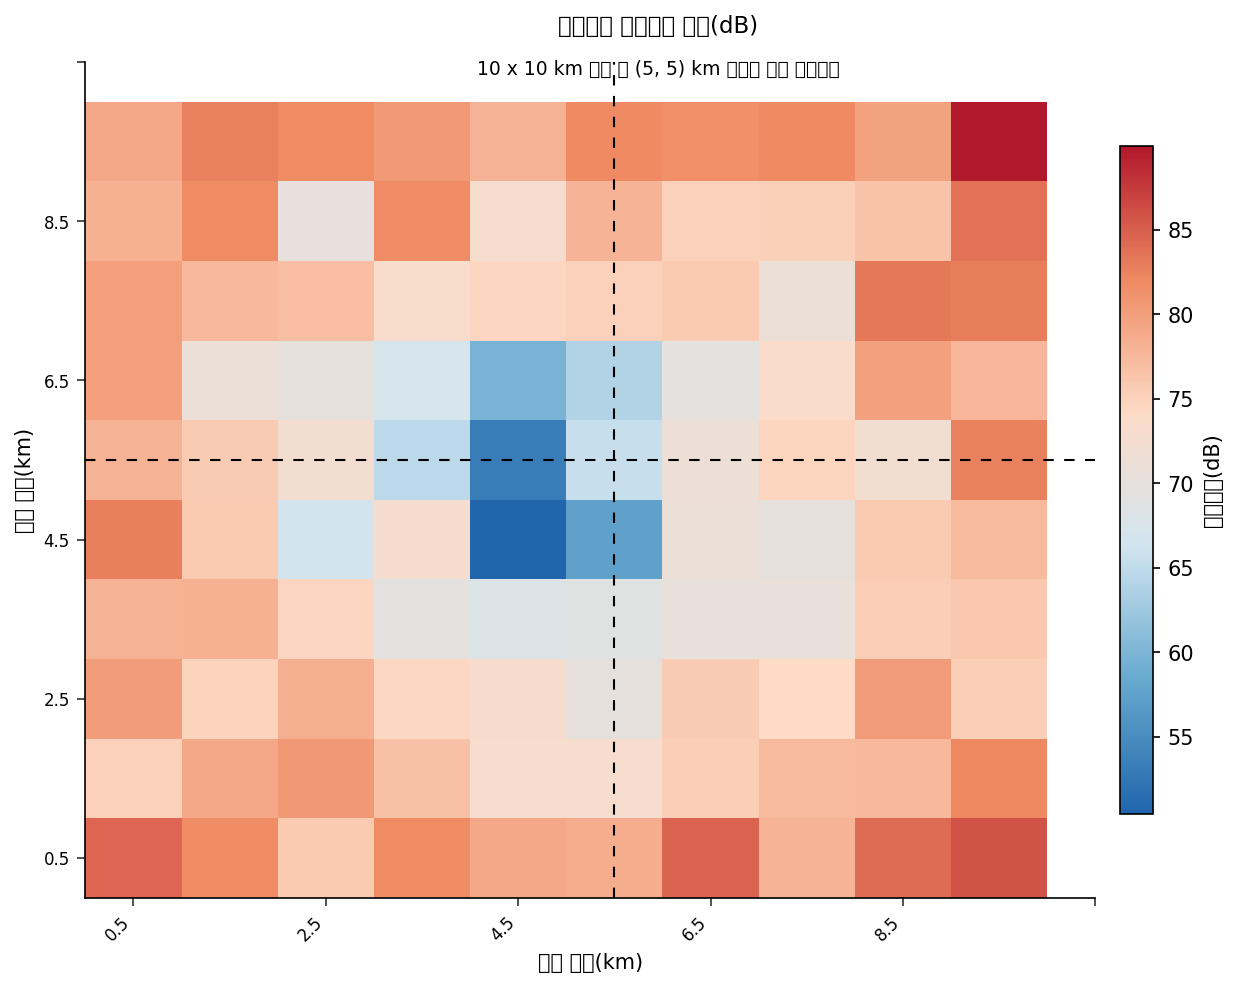

In [4]:
ODS GRAPHICS ON;
제목 "하향링크 경로손실 곡면(dB)";
title2 "10 x 10 km 격자 위 (5, 5) km 지점의 단일 매크로셀";

처리 SGPLOT 데이터=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / 제목="경로손실(dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) 라벨="동쪽 거리(km)";
   YAXIS VALUES=(0 2 4 6 8 10) 라벨="북쪽 거리(km)";
실행;

제목; title2;


## 5단계 — 커버리지 등급 분포

브리핑 슬라이드에는 핵심 비율도 필요합니다: 커버리지 영역 중 강함, 양호, 약함이 각각 얼마인지입니다. `zone` 분류에 대한 `VBAR`가 이를 한눈에 보여주며 위의 등고선 곡면과 짝을 이룹니다.

                                                       커버리지 등급 분포                                                       




NOTE: Option TITLE changed to 커버리지 등급 분포.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


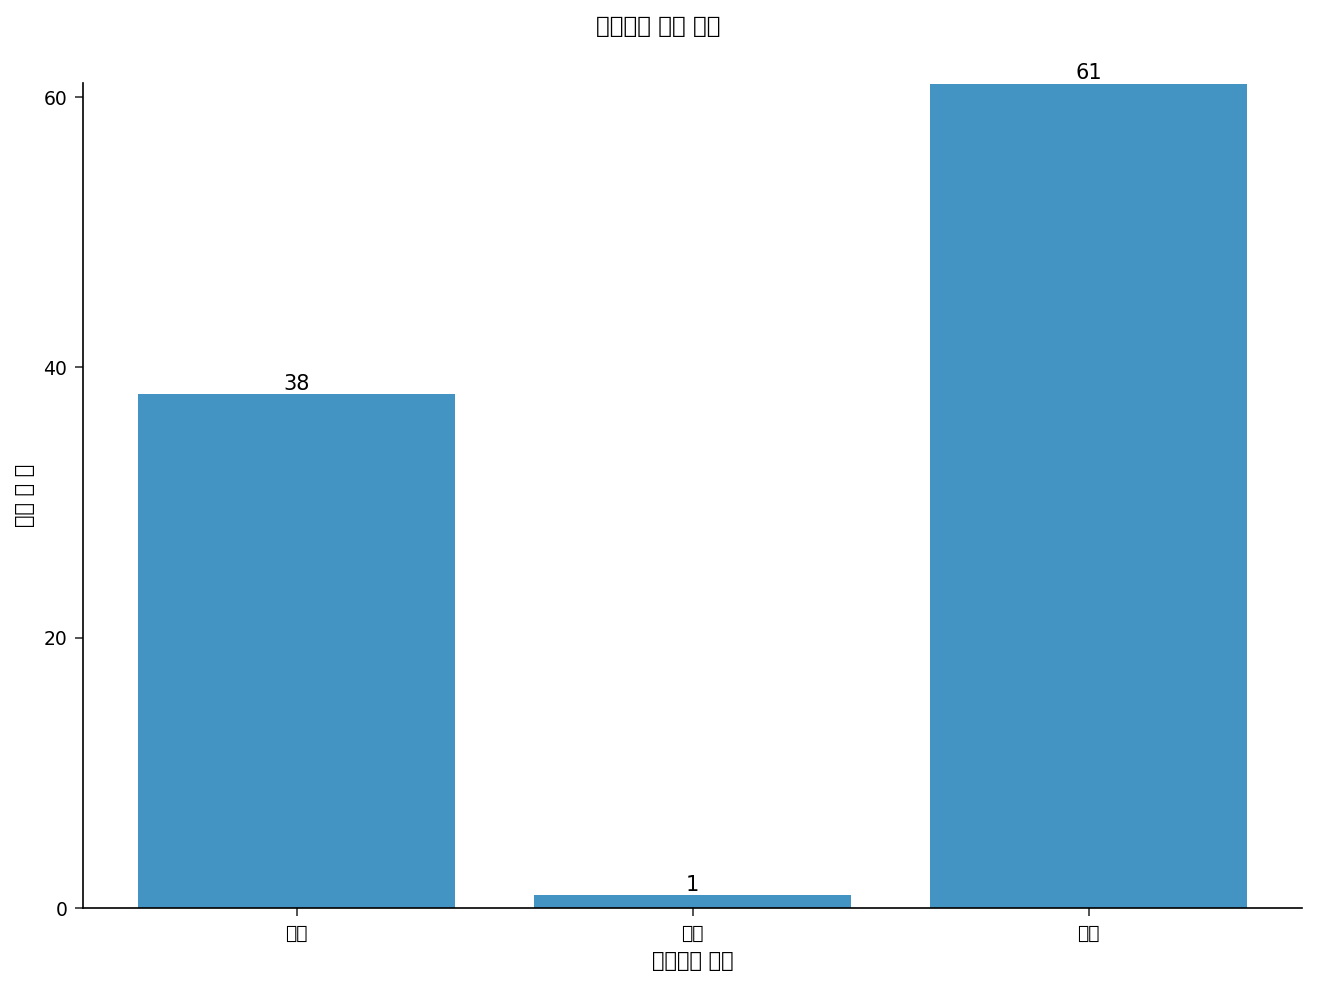

In [5]:
제목 "커버리지 등급 분포";

처리 SGPLOT 데이터=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS 라벨="커버리지 등급";
   YAXIS 라벨="격자 셀 수" VALUES=(0 20 40 60);
실행;

제목;


## 결과 해석

등고선 곡면은 예상된 전파 물리 특성을 확인해 줍니다. 경로손실은 **(5, 5) km 기지국 주변의 좁은 파란색 저점**에서 가장 낮고 — 수신 신호가 가장 좋은 강함 구역입니다 — 모서리 쪽으로 갈수록 거리의 로그에 비례해 증가합니다. 로그정규 섀도우 페이딩을 주입했기 때문에 밴드는 동심원이 아닙니다. 경계를 따라 나타나는 들쭉날쭉한 빨간 셀들이 섀도우로 페이딩된 가장자리입니다.

실질적으로 주목할 결과는 **(9.5, 9.5) km에 있는 단 하나의 약함 셀(89.97 dB)**로, 기지국의 대각선 반대편 모서리이자 88 dB 설계 임계값을 넘는 유일한 지점입니다. **100개 중 61개 셀이 양호하고 단 1개만 약함**인 이 매크로셀은 서비스 영역을 잘 커버하고 있습니다. 이 하나의 구멍은 알려진 수요 핫스팟과 겹칠 때만 **소형셀 보강이나 북동쪽 모서리로의 섹터 재조정**을 정당화할 것입니다. 등고선 곡면은 브리핑에 바로 쓸 수 있는 요약이며, 커버리지 등급 막대 차트는 용량 계획자가 상부에 보고할 한 줄짜리 비율을 제공합니다.